In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load Dataset
df = pd.read_csv(r"C:\Users\khush\OneDrive\Desktop\phase3_dataset.csv")
df.head()


,LoanAmount_ApplicantIncome_Married_Factor,SemiurbanArea_UrbanArea_LoanAmount_Factor,RuralArea_UrbanArea_Education_Factor,Married_SemiurbanArea_ApplicantIncome_Factor,CoapplicantIncome_Education_CreditHistory_Factor,CreditHistory_SelfEmployed_LoanTerm_Factor,CoapplicantIncome_LoanTerm_SelfEmployed_Factor,SelfEmployed_LoanTerm_ApplicantIncome_Factor,Education_CreditHistory_LoanTerm_Factor,Dependents_Gender_Education_Factor,Married_Gender_Dependents_Factor,Loan_Default
0,-0.787046,-0.948399,-1.202561,-1.330961,0.178757,0.240052,-0.774039,-0.031139,-0.062352,-0.612304,-0.961355,0
1,0.597363,-0.544571,1.616087,0.045645,0.801464,0.266839,-0.744045,-0.032902,0.616600,0.338229,0.183640,1
2,-0.051093,-1.067766,-1.103192,-0.403624,-0.590985,1.427442,0.030567,2.478202,0.838735,-0.736132,0.605984,0
3,-0.318176,-1.823533,-0.735293,0.614173,-0.017963,0.007744,-0.321916,0.285848,-1.688150,-0.827922,0.803372,0
4,-0.698184,-0.902184,-1.210384,-1.387338,0.186455,0.220478,-0.765344,-0.053289,-0.108054,-0.621768,-0.947942,0


In [8]:
# Split X and y

X = df.drop('Loan_Default', axis=1)
y = df['Loan_Default']

train_scores = []
test_scores = []


In [9]:
print("\n--- Split Ratio 60:40 ---")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.4,
    random_state=42
)

sc = StandardScaler()

X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

svm = SVC(kernel='rbf', C=1, gamma='scale')

svm.fit(X_train_scaled, y_train)

train_pred = svm.predict(X_train_scaled)
test_pred = svm.predict(X_test_scaled)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

print(classification_report(y_test, test_pred))

train_scores.append(train_acc)
test_scores.append(test_acc)



--- Split Ratio 60:40 ---
Train Accuracy: 0.8315217391304348
Test Accuracy: 0.8008130081300813
              precision    recall  f1-score   support

           0       0.77      0.99      0.87       161
           1       0.97      0.44      0.60        85

    accuracy                           0.80       246
   macro avg       0.87      0.71      0.73       246
weighted avg       0.84      0.80      0.78       246



In [10]:
print("\n--- Split Ratio 70:30 ---")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

sc = StandardScaler()

X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

svm = SVC(kernel='rbf', C=1, gamma='scale')

svm.fit(X_train_scaled, y_train)

train_pred = svm.predict(X_train_scaled)
test_pred = svm.predict(X_test_scaled)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

print(classification_report(y_test, test_pred))

train_scores.append(train_acc)
test_scores.append(test_acc)



--- Split Ratio 70:30 ---
Train Accuracy: 0.8321678321678322
Test Accuracy: 0.7891891891891892
              precision    recall  f1-score   support

           0       0.76      0.99      0.86       120
           1       0.96      0.42      0.58        65

    accuracy                           0.79       185
   macro avg       0.86      0.70      0.72       185
weighted avg       0.83      0.79      0.76       185



In [11]:
print("\n--- Split Ratio 80:20 ---")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

sc = StandardScaler()

X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

svm = SVC(kernel='rbf', C=1, gamma='scale')

svm.fit(X_train_scaled, y_train)

train_pred = svm.predict(X_train_scaled)
test_pred = svm.predict(X_test_scaled)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

print(classification_report(y_test, test_pred))

train_scores.append(train_acc)
test_scores.append(test_acc)



--- Split Ratio 80:20 ---
Train Accuracy: 0.8329938900203666
Test Accuracy: 0.7886178861788617
              precision    recall  f1-score   support

           0       0.76      0.99      0.86        80
           1       0.95      0.42      0.58        43

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



In [12]:
results_svm = {
    "train": train_scores,
    "test": test_scores
}

print(results_svm)


{'train': [0.8315217391304348, 0.8321678321678322, 0.8329938900203666], 'test': [0.8008130081300813, 0.7891891891891892, 0.7886178861788617]}


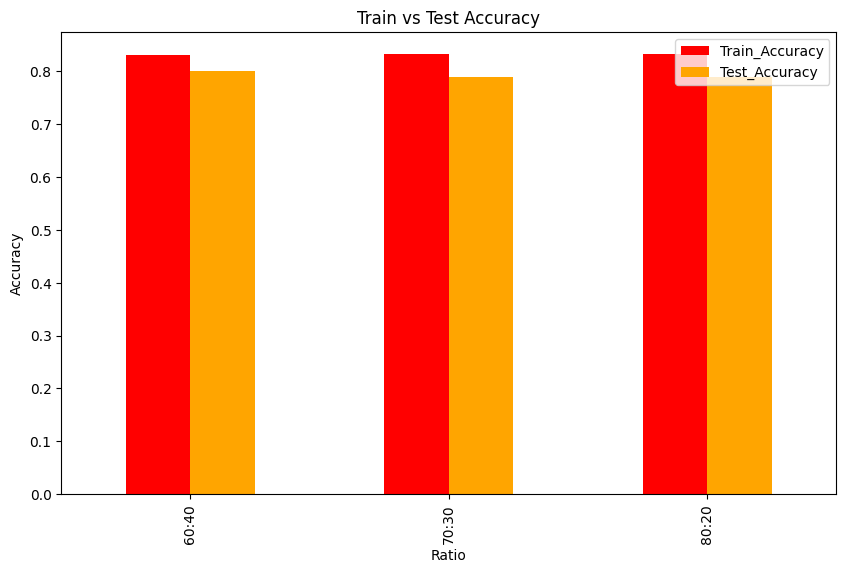

In [13]:
# Bar Graph

data = {
    'Ratio': ['60:40', '70:30', '80:20'],
    'Train_Accuracy': train_scores,
    'Test_Accuracy': test_scores
}

df_results = pd.DataFrame(data)

df_results.plot(
    x='Ratio',
    y=['Train_Accuracy', 'Test_Accuracy'],
    kind='bar',
    figsize=(10,6),
    color=['red', 'orange']
)

plt.title("Train vs Test Accuracy")
plt.ylabel("Accuracy")

plt.show()


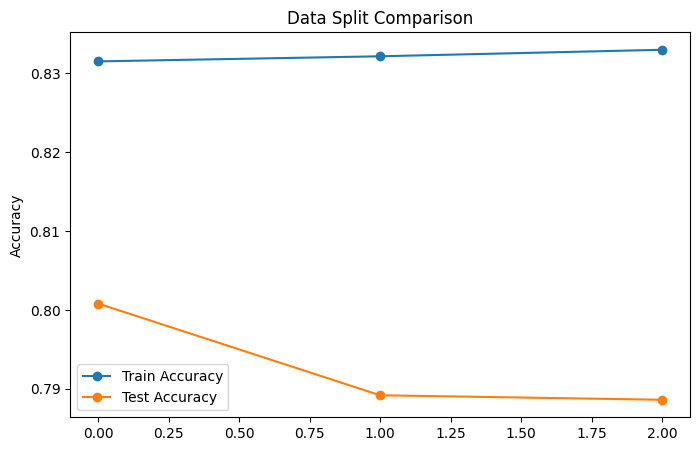

In [14]:
# Line Graph

plt.figure(figsize=(8,5))

plt.plot(df_results["Train_Accuracy"], marker='o', label="Train Accuracy")
plt.plot(df_results["Test_Accuracy"], marker='o', label="Test Accuracy")

plt.title("Data Split Comparison")
plt.ylabel("Accuracy")

plt.legend()

plt.show()


In [15]:
# Final Model Training

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

sc = StandardScaler()

X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

fin_model = SVC(kernel='rbf', C=1, gamma='scale')

fin_model.fit(X_train_scaled, y_train)

y_pred = fin_model.predict(X_test_scaled)


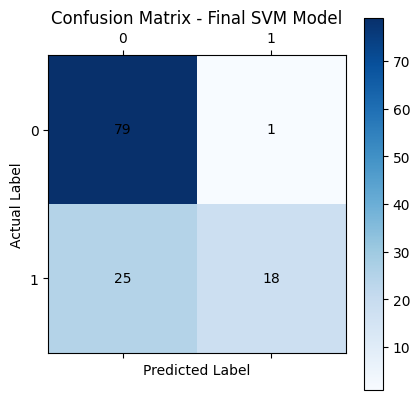

In [16]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.matshow(cm, cmap='Blues')

plt.title("Confusion Matrix - Final SVM Model")
plt.colorbar()

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center')

plt.show()


In [17]:
# User Input Prediction

print("\nEnter applicant details:\n")

data_new = {
    'Gender': input("Gender (Male/Female): "),
    'Married': input("Married (Yes/No): "),
    'Dependents': input("Dependents (0/1/2/3+): "),
    'Education': input("Education (Graduate/Not Graduate): "),
    'Self_Employed': input("Self Employed (Yes/No): "),
    'ApplicantIncome': float(input("Applicant Income: ")),
    'CoapplicantIncome': float(input("Coapplicant Income: ")),
    'LoanAmount': float(input("Loan Amount: ")),
    'Loan_Amount_Term': float(input("Loan Term: ")),
    'Credit_History': float(input("Credit History (1/0): ")),
    'Property_Area': input("Property Area (Urban/Semiurban/Rural): ")
}

input_df = pd.DataFrame([data_new])

input_df = pd.get_dummies(input_df, drop_first=True)

input_df = input_df.reindex(columns=X.columns, fill_value=0)

input_scaled = sc.transform(input_df)

prediction = fin_model.predict(input_scaled)[0]

if prediction == 1:
    result = "Yes"
else:
    result = "No"

print("\nPrediction Result:")
print("Loan Default:", result)



Enter applicant details:


Prediction Result:
Loan Default: No
